# Sistema de clasificación de imágenes: perros vs. gatos

Clasificador de fotos de perros y gatos (dataset *Asirra*, Petfinder.com + Microsoft) con una red neuronal convolucional basada en **EfficientNet-B0**.

Referencia histórica: en 2007, un SVM alcanzó un **80 %** de precisión en esta tarea ("Machine Learning Attacks Against the Asirra CAPTCHA").

**Pasos:**
1. Carga del conjunto de datos
2. Visualización y preprocesado de las imágenes
3. Construcción y entrenamiento de la RNA base
4. Optimización con `ModelCheckpoint` y `EarlyStopping`
5. Guardado del modelo

In [1]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import keras
from keras.applications import EfficientNetB0
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.preprocessing.image import load_img
# En Keras 3, ImageDataGenerator solo se conserva como API heredada
from keras.src.legacy.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
RAW_DIR = Path("../data/raw/train")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

IMG_SIZE = (200, 200)    # tamaño fijo del preprocesado
INPUT_SIZE = (224, 224)  # resolución de entrada de EfficientNet-B0
BATCH_SIZE = 16          # cabe en una GPU de 4 GB
EPOCHS_BASELINE = 3
EPOCHS_OPTIMIZED = 10

keras.utils.set_random_seed(SEED)
# Precisión mixta: reduce a la mitad la memoria de la GPU y acelera el entrenamiento
keras.mixed_precision.set_global_policy("mixed_float16")
print(f"Keras {keras.__version__} | backend: {keras.backend.backend()}")

Keras 3.15.1 | backend: torch


## Paso 1: Carga del conjunto de datos

El dataset se descargó de [este enlace](https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip) y se descomprimió en `data/raw/train`. Cada foto está etiquetada por su nombre de archivo (`cat.<n>.jpg` o `dog.<n>.jpg`).

In [2]:
def file_number(name):
    return int(name.split(".")[1])


files = sorted(os.listdir(RAW_DIR), key=lambda f: (f.split(".")[0], file_number(f)))
cat_files = [f for f in files if f.startswith("cat")]
dog_files = [f for f in files if f.startswith("dog")]

print(f"Total de imágenes: {len(files)}")
print(f"Gatos: {len(cat_files)} | Perros: {len(dog_files)}")

Total de imágenes: 25000
Gatos: 12500 | Perros: 12500


El dataset está perfectamente balanceado (12.500 imágenes por clase), así que la *accuracy* es una métrica adecuada.

## Paso 2: Visualiza la información de entrada

### Primeras nueve fotos de cada clase

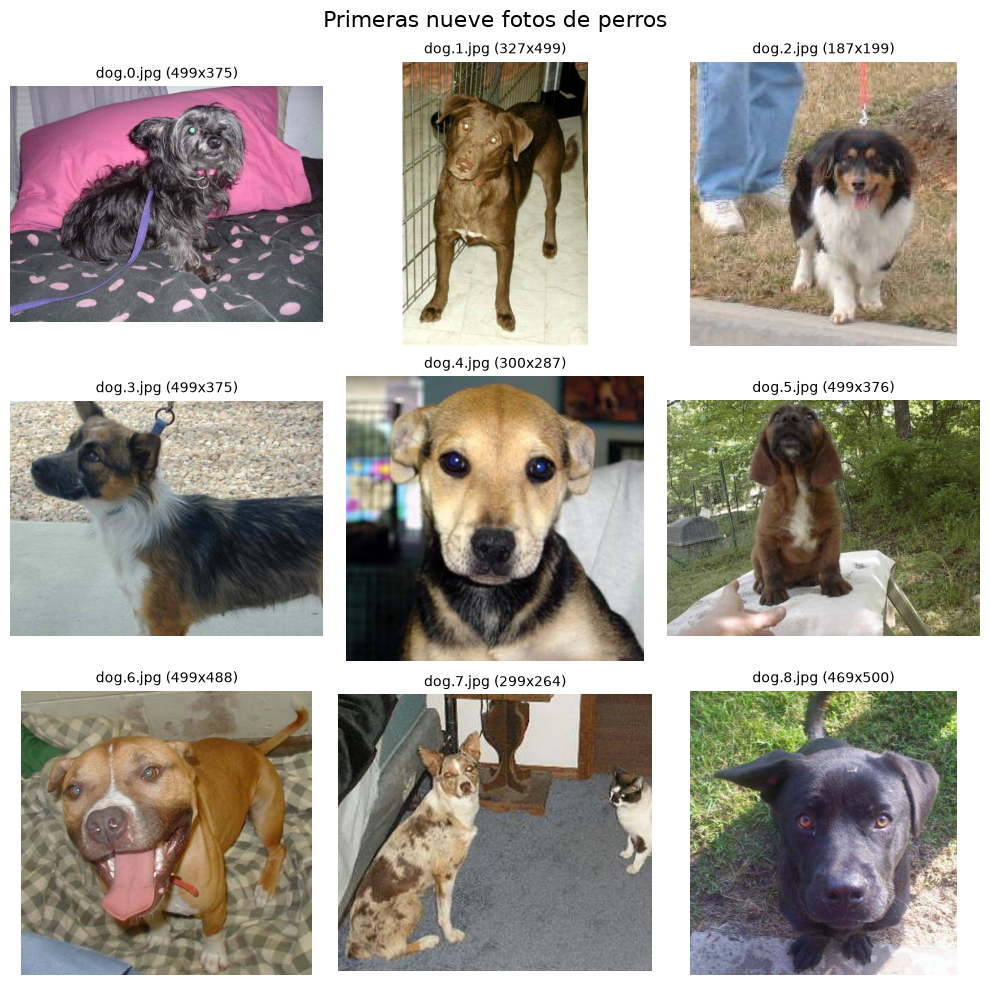

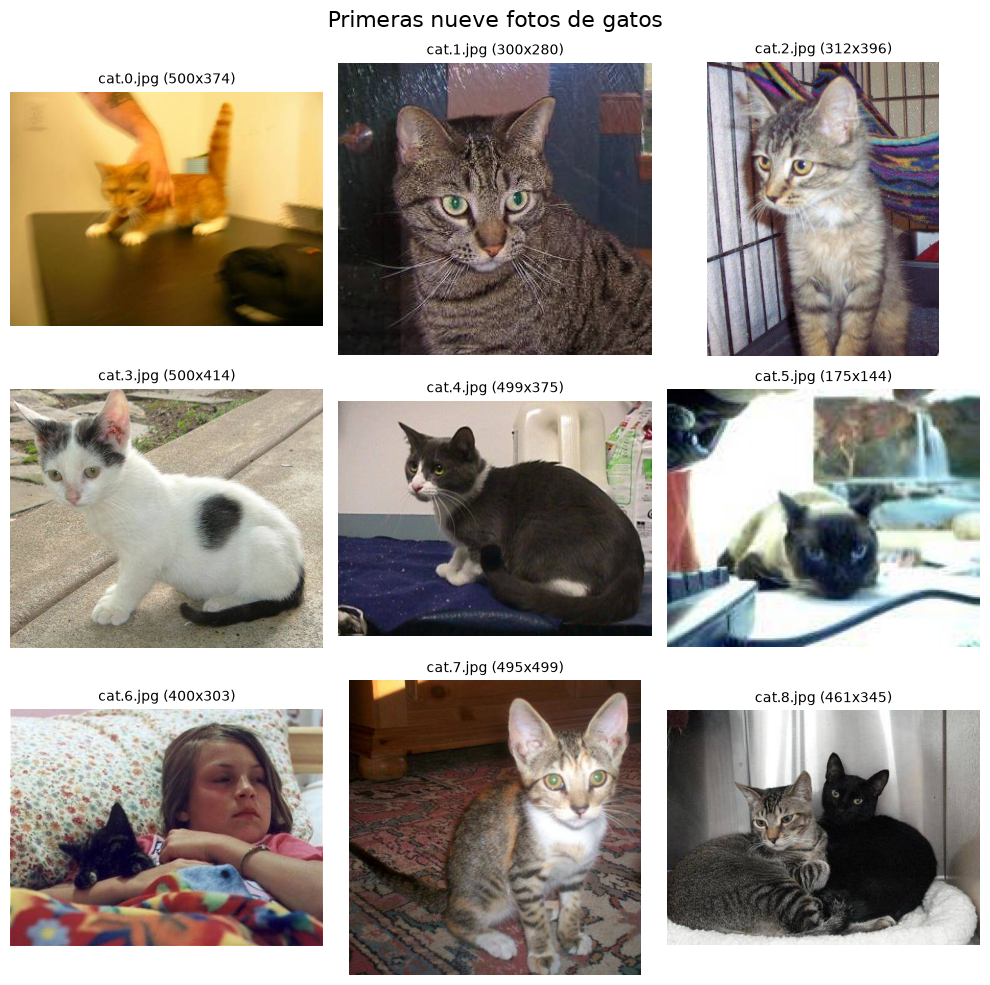

In [3]:
def plot_first_nine(file_names, title):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for ax, name in zip(axes.flat, file_names[:9]):
        img = load_img(RAW_DIR / name)
        ax.imshow(img)
        ax.set_title(f"{name} ({img.size[0]}x{img.size[1]})", fontsize=10)
        ax.axis("off")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


plot_first_nine(dog_files, "Primeras nueve fotos de perros")
plot_first_nine(cat_files, "Primeras nueve fotos de gatos")

Las fotos son a color y tienen tamaños y proporciones muy distintos. Además, en algunas el animal aparece en una esquina, parcialmente tapado, acompañado de personas o hay más de un animal. Veamos la distribución de tamaños de todo el dataset:

         width   height
count  25000.0  25000.0
mean     404.1    360.5
std      109.0     97.0
min       42.0     32.0
25%      323.0    301.0
50%      447.0    374.0
75%      499.0    421.0
max     1050.0    768.0


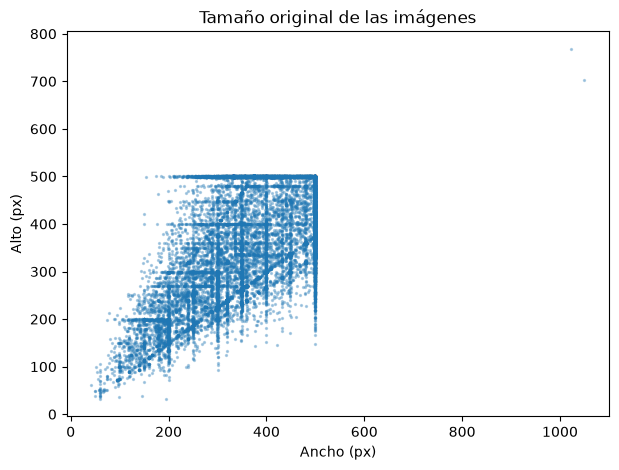

In [4]:
sizes = pd.DataFrame(
    [Image.open(RAW_DIR / f).size for f in files], columns=["width", "height"]
)
print(sizes.describe().round(1))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sizes["width"], sizes["height"], s=2, alpha=0.3)
ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")
ax.set_title("Tamaño original de las imágenes")
plt.show()

### Carga progresiva de las imágenes con `ImageDataGenerator`

Cargar las 25.000 fotos en memoria a la vez necesitaría unos 3 GB en `uint8` y 12 GB en `float32`. Por eso se cargan **progresivamente** con `ImageDataGenerator` y `flow_from_directory()`. Este método lee del disco solo el lote que necesita en cada paso, así que es más lento pero funciona en equipos con poca RAM.

`flow_from_directory()` espera los datos divididos en directorios `train` y `test`, con una subcarpeta por clase. Por eso se reparten las fotos en `data/processed/{train,test}/{cats,dogs}` con una división estratificada 80/20. La etiqueta se determina a partir del nombre del archivo (`cat.*` → `cats`, `dog.*` → `dogs`).

In [5]:
labels = [name.split(".")[0] for name in files]
train_files, test_files = train_test_split(
    files, test_size=0.2, stratify=labels, random_state=SEED
)

for split, names in [("train", train_files), ("test", test_files)]:
    split_dir = PROCESSED_DIR / split
    if split_dir.exists():
        shutil.rmtree(split_dir)
    for name in names:
        class_dir = split_dir / ("dogs" if name.startswith("dog") else "cats")
        class_dir.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(RAW_DIR / name, class_dir / name)

print(f"Train: {len(train_files)} | Test: {len(test_files)}")

Train: 20000 | Test: 5000


Cada lote que entrega el generador es una tupla `(fotos, etiquetas)`. Con `target_size=(200, 200)` todas las fotos quedan con un tamaño fijo de 200x200 px, sea cual sea su forma original:

Found 20000 images belonging to 2 classes.


photos: (12, 200, 200, 3) | labels: (12, 2)


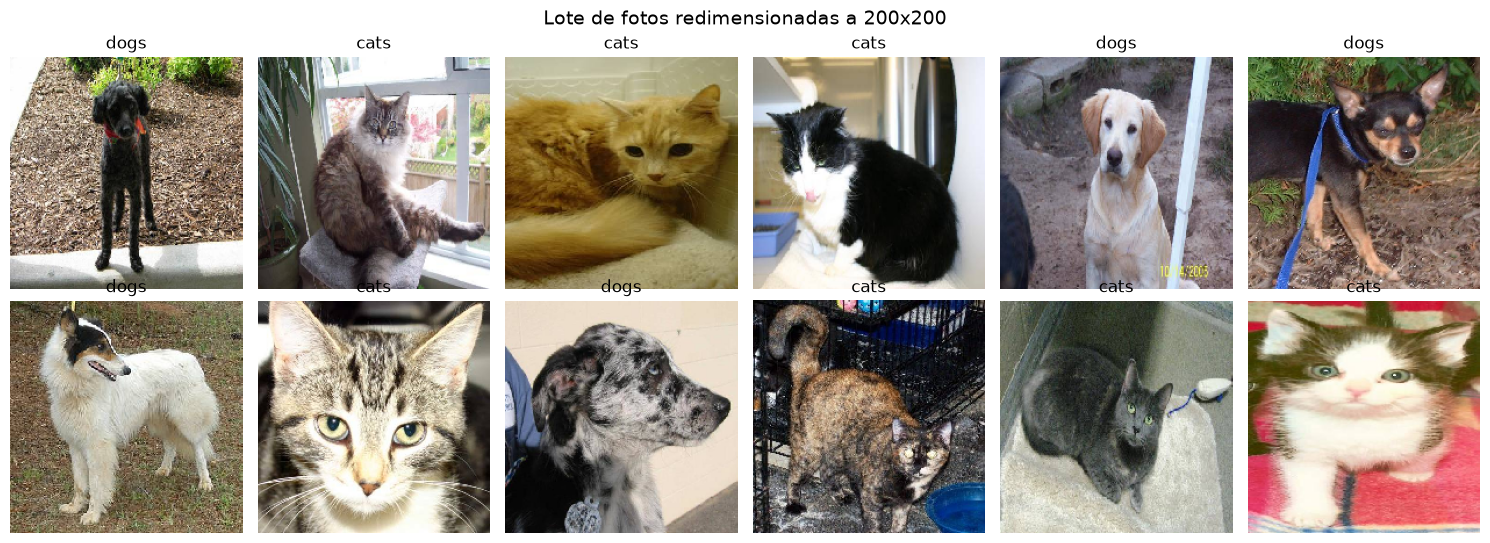

In [6]:
preview_data = ImageDataGenerator().flow_from_directory(
    PROCESSED_DIR / "train", target_size=IMG_SIZE, batch_size=12, seed=SEED,
)
photos, photo_labels = preview_data[0]
print(f"photos: {photos.shape} | labels: {photo_labels.shape}")

preview_classes = list(preview_data.class_indices)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, photo, label in zip(axes.flat, photos, photo_labels):
    ax.imshow(photo.astype("uint8"))
    ax.set_title(preview_classes[label.argmax()])
    ax.axis("off")
fig.suptitle("Lote de fotos redimensionadas a 200x200", fontsize=14)
plt.tight_layout()
plt.show()

### Generadores de entrenamiento, validación y test

Del conjunto de entrenamiento se reserva un 15 % como validación, que usarán las callbacks del paso 4. Como la arquitectura propuesta usa una entrada de 224x224, los generadores del modelo redimensionan a ese tamaño. No se reescalan los píxeles a [0, 1] porque `EfficientNetB0` de Keras ya incluye su propia capa de normalización y espera valores en [0, 255].

In [7]:
trdata = ImageDataGenerator(validation_split=0.15)
train_data = trdata.flow_from_directory(
    PROCESSED_DIR / "train", target_size=INPUT_SIZE, batch_size=BATCH_SIZE,
    subset="training", seed=SEED,
)
val_data = trdata.flow_from_directory(
    PROCESSED_DIR / "train", target_size=INPUT_SIZE, batch_size=BATCH_SIZE,
    subset="validation", shuffle=False,
)

tsdata = ImageDataGenerator()
test_data = tsdata.flow_from_directory(
    PROCESSED_DIR / "test", target_size=INPUT_SIZE, batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = list(test_data.class_indices)
print(test_data.class_indices)

Found 17000 images belonging to 2 classes.


Found 3000 images belonging to 2 classes.


Found 5000 images belonging to 2 classes.


{'cats': 0, 'dogs': 1}


## Paso 3: Construye una RNA

Arquitectura de prueba propuesta: backbone convolucional de `EfficientNet-B0` **sin pesos preentrenados** (`weights=None`), `GlobalAveragePooling2D` y dos capas densas para la clasificación perro/gato.

Para completar el modelo se añade el optimizador Adam, la pérdida `categorical_crossentropy` (salida softmax de 2 unidades con etiquetas one-hot) y la métrica *accuracy*. La capa de salida se calcula en `float32` para que la softmax sea numéricamente estable con precisión mixta.

> Nota: en Keras 3 `fit_generator` ya no existe; `fit` acepta los generadores directamente.

In [8]:
model = Sequential()
model.add(EfficientNetB0(include_top=False, weights=None, input_shape=(224, 224, 3)))
model.add(GlobalAveragePooling2D())
model.add(Dense(units=128, activation="relu"))
model.add(Dense(units=2, activation="softmax", dtype="float32"))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 4,171,774 (15.91 MB)

 Non-trainable params: 42,023 (164.15 KB)

In [9]:
history = model.fit(train_data, validation_data=val_data, epochs=EPOCHS_BASELINE, verbose=2)

Epoch 1/3


1063/1063 - 567s - 534ms/step - accuracy: 0.6157 - loss: 0.6697 - val_accuracy: 0.6753 - val_loss: 0.6348


Epoch 2/3


1063/1063 - 434s - 409ms/step - accuracy: 0.7158 - loss: 0.5589 - val_accuracy: 0.7547 - val_loss: 0.5100


Epoch 3/3


1063/1063 - 430s - 404ms/step - accuracy: 0.7985 - loss: 0.4442 - val_accuracy: 0.6947 - val_loss: 0.6692


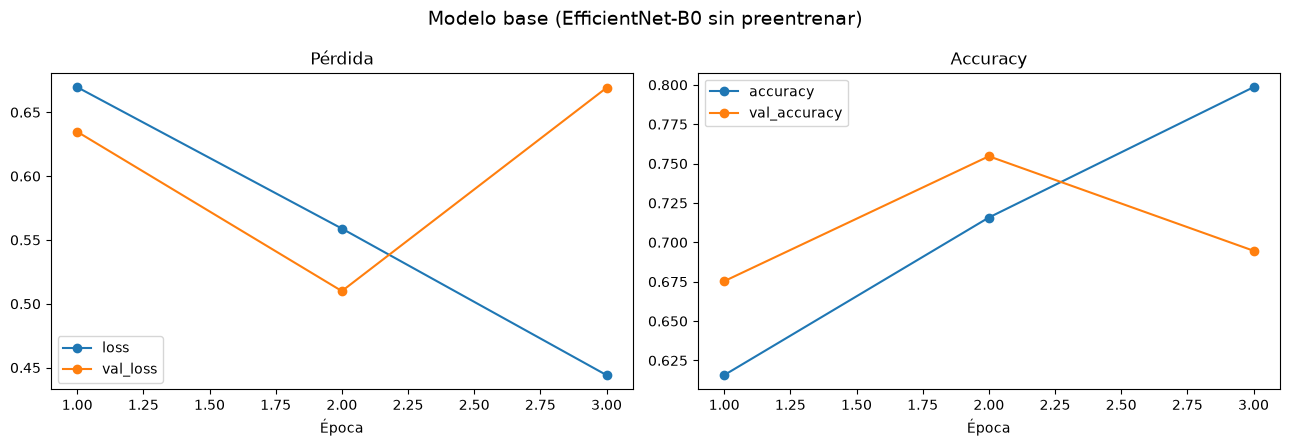

Modelo base -> test loss: 0.6776 | test accuracy: 0.6852


In [10]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    hist.index += 1
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    hist[["loss", "val_loss"]].plot(ax=axes[0], marker="o", title="Pérdida")
    hist[["accuracy", "val_accuracy"]].plot(ax=axes[1], marker="o", title="Accuracy")
    for ax in axes:
        ax.set_xlabel("Época")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_history(history, "Modelo base (EfficientNet-B0 sin preentrenar)")

baseline_loss, baseline_acc = model.evaluate(test_data, verbose=0)
print(f"Modelo base -> test loss: {baseline_loss:.4f} | test accuracy: {baseline_acc:.4f}")

Entrenar EfficientNet-B0 desde cero (4 millones de parámetros) con solo 17.000 imágenes y pocas épocas da un resultado limitado: la red tiene que aprender desde cero todos los filtros visuales.

## Paso 4: Optimiza el modelo anterior

Mejoras aplicadas sobre la arquitectura base:

1. **Transfer learning**: backbone inicializado con los pesos de **ImageNet** (`weights="imagenet"`), que ya sabe detectar bordes, texturas y formas, incluidas las de perros y gatos.
2. **Learning rate bajo** (`1e-4`) para ajustar los pesos preentrenados sin destruirlos (*fine-tuning*).
3. **Data augmentation** en el entrenamiento (volteo horizontal, rotación, zoom y desplazamientos). Ayuda a la robustez frente a animales descentrados o en esquinas.
4. **Dropout** antes y después de la capa densa para reducir el sobreajuste.
5. **Callbacks**: `ModelCheckpoint` guarda el mejor modelo según `val_loss` y `EarlyStopping` detiene el entrenamiento cuando deja de mejorar.

El generador de validación es el mismo de antes (sin augmentation). La partición `validation_split` es determinista, así que ambos generadores usan exactamente las mismas imágenes de validación.

In [11]:
trdata_aug = ImageDataGenerator(
    validation_split=0.15,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
train_data_aug = trdata_aug.flow_from_directory(
    PROCESSED_DIR / "train", target_size=INPUT_SIZE, batch_size=BATCH_SIZE,
    subset="training", seed=SEED,
)

opt_model = Sequential()
opt_model.add(EfficientNetB0(include_top=False, weights="imagenet", input_shape=(224, 224, 3)))
opt_model.add(GlobalAveragePooling2D())
opt_model.add(Dropout(0.3))
opt_model.add(Dense(units=128, activation="relu"))
opt_model.add(Dropout(0.3))
opt_model.add(Dense(units=2, activation="softmax", dtype="float32"))

opt_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Found 17000 images belonging to 2 classes.


In [12]:
checkpoint_path = MODELS_DIR / "checkpoints" / "efficientnetb0_best.keras"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path), monitor="val_loss", save_best_only=True, verbose=1
)
early_stopping = EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True, verbose=1
)

history_opt = opt_model.fit(
    train_data_aug,
    validation_data=val_data,
    epochs=EPOCHS_OPTIMIZED,
    callbacks=[checkpoint, early_stopping],
    verbose=2,
)

Epoch 1/10



Epoch 1: val_loss improved from None to 0.03353, saving model to ..\models\checkpoints\efficientnetb0_best.keras



Epoch 1: finished saving model to ..\models\checkpoints\efficientnetb0_best.keras


1063/1063 - 533s - 501ms/step - accuracy: 0.9586 - loss: 0.1080 - val_accuracy: 0.9877 - val_loss: 0.0335


Epoch 2/10


...

Epoch 5/10



Epoch 5: val_loss did not improve from 0.03135


1063/1063 - 549s - 517ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9900 - val_loss: 0.0343


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 3.


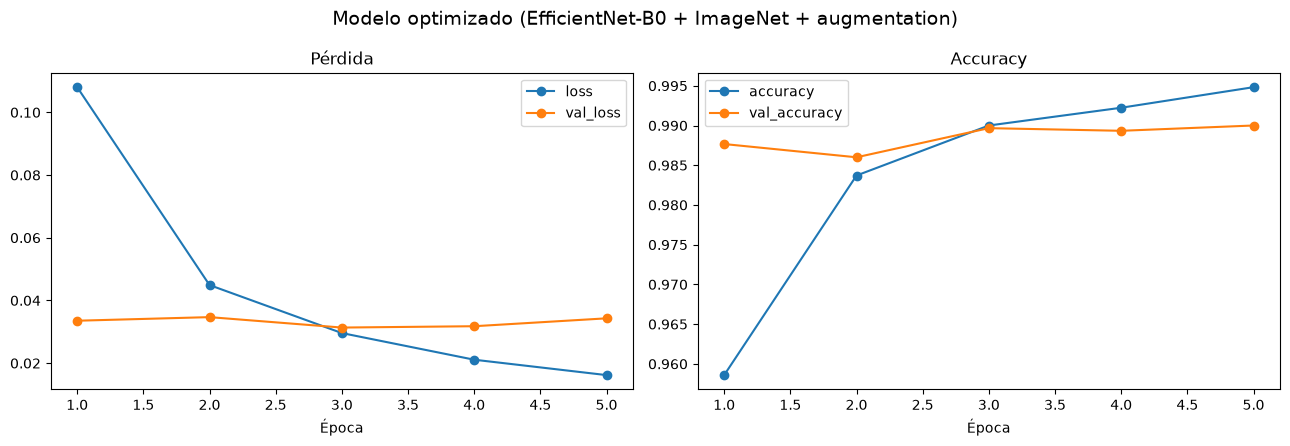

In [13]:
plot_history(history_opt, "Modelo optimizado (EfficientNet-B0 + ImageNet + augmentation)")

### Carga del mejor modelo y predicciones sobre el conjunto de test

In [14]:
best_model = load_model(checkpoint_path)

y_prob = best_model.predict(test_data, verbose=0)
y_pred = y_prob.argmax(axis=1)
y_true = test_data.classes

optimized_acc = accuracy_score(y_true, y_pred)
print(f"Accuracy en test del mejor modelo: {optimized_acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Accuracy en test del mejor modelo: 0.9890

              precision    recall  f1-score   support

        cats     0.9842    0.9940    0.9891      2500
        dogs     0.9939    0.9840    0.9889      2500

    accuracy                         0.9890      5000
   macro avg     0.9890    0.9890    0.9890      5000
weighted avg     0.9890    0.9890    0.9890      5000



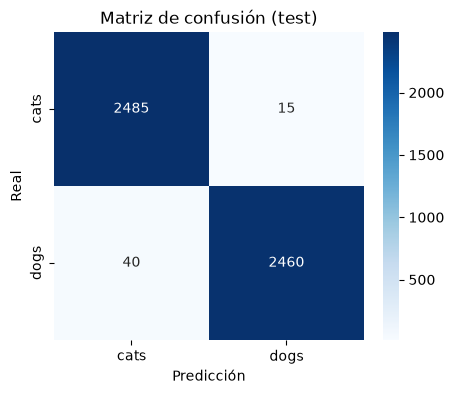

In [15]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión (test)")
plt.show()

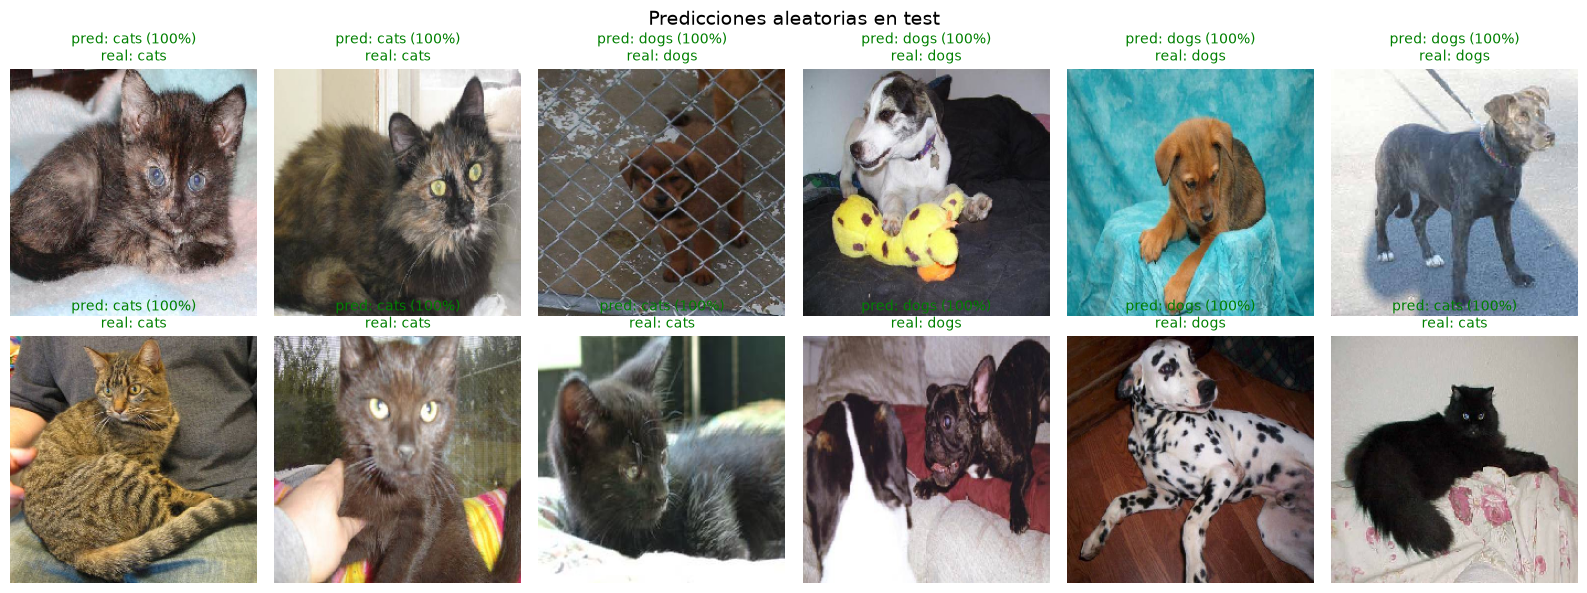

Errores: 55 de 5000


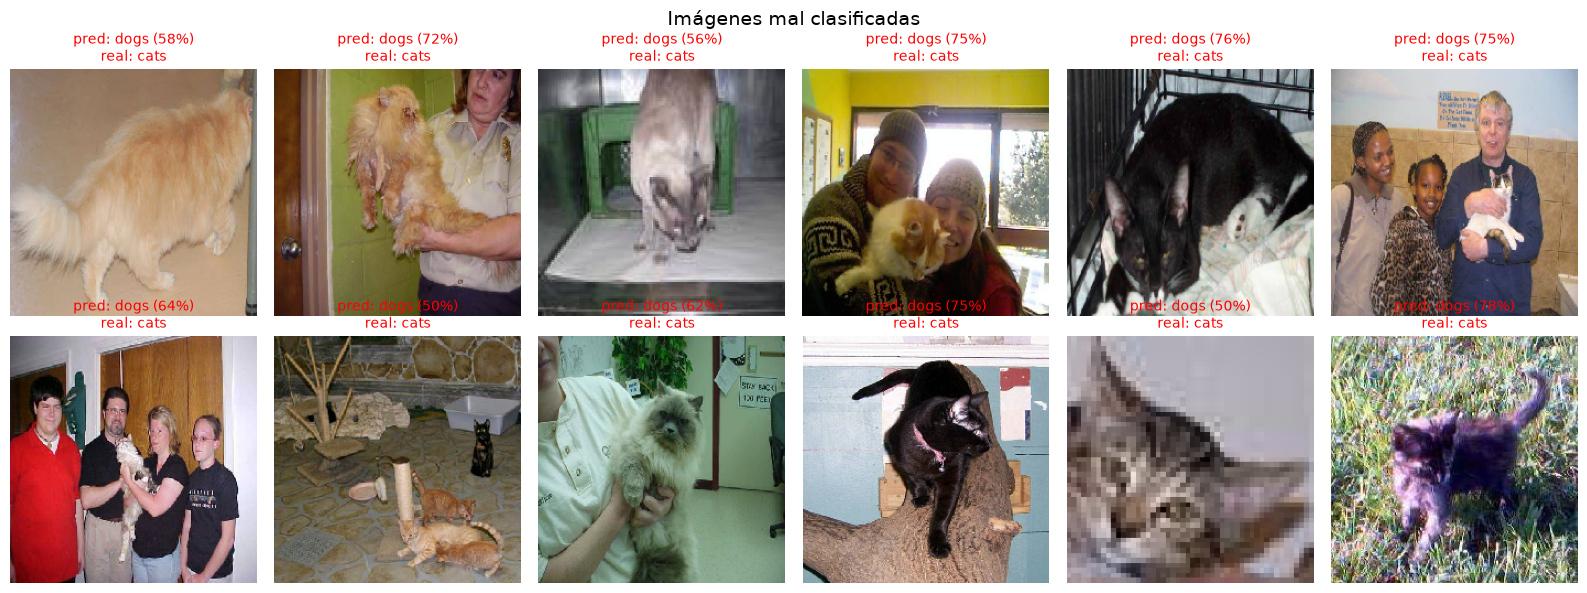

In [16]:
def plot_predictions(indices, title):
    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    for ax, idx in zip(axes.flat, indices):
        ax.imshow(load_img(test_data.filepaths[idx], target_size=INPUT_SIZE))
        ok = y_pred[idx] == y_true[idx]
        ax.set_title(
            f"pred: {class_names[y_pred[idx]]} ({y_prob[idx].max():.0%})\nreal: {class_names[y_true[idx]]}",
            color="green" if ok else "red", fontsize=10,
        )
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(SEED)
plot_predictions(rng.choice(len(y_true), 12, replace=False), "Predicciones aleatorias en test")

errors = np.flatnonzero(y_pred != y_true)
print(f"Errores: {len(errors)} de {len(y_true)}")
plot_predictions(errors[:12], "Imágenes mal clasificadas")

In [17]:
results = pd.DataFrame({
    "Modelo": ["SVM (Golle, 2007)", "EfficientNet-B0 sin preentrenar", "EfficientNet-B0 optimizado"],
    "Accuracy test": [0.80, baseline_acc, optimized_acc],
})
results.round(4)

,Modelo,Accuracy test
0,"SVM (Golle, 2007)",0.8000
1,EfficientNet-B0 sin preentrenar,0.6852
2,EfficientNet-B0 optimizado,0.9890


## Paso 5: Guarda el modelo

El mejor modelo se guarda en la carpeta `models/` en formato nativo de Keras (`.keras`), sin el estado del optimizador. Se puede usar con `src/app.py` para clasificar nuevas imágenes.

In [18]:
# Sin el estado del optimizador (compile=False): basta para predecir y ocupa ~5 veces menos
final_model = load_model(checkpoint_path, compile=False)

final_model_path = MODELS_DIR / "dogs_vs_cats_efficientnetb0.keras"
final_model.save(final_model_path)
print(f"Modelo guardado en {final_model_path} ({final_model_path.stat().st_size / 1e6:.1f} MB)")

Modelo guardado en ..\models\dogs_vs_cats_efficientnetb0.keras (17.7 MB)


## Conclusiones

| Modelo | Accuracy en test |
|---|---|
| SVM (Golle, 2007) | 80,0 % |
| EfficientNet-B0 sin preentrenar (3 épocas) | 68,5 % |
| **EfficientNet-B0 optimizado (ImageNet + augmentation + callbacks)** | **98,9 %** |

- **Datos**: 25.000 fotos perfectamente balanceadas, de tamaños muy variados (de 42x32 a 1050x768 px). Se cargan progresivamente con `ImageDataGenerator` + `flow_from_directory()`, sin necesidad de tener todo el dataset en memoria.
- **Modelo base**: entrenar EfficientNet-B0 desde cero es lento y poco estable. En 3 épocas llegó al 80 % en entrenamiento, pero la validación oscila (75 % → 69 %) y en test se queda en un 68,5 %, por debajo del SVM de 2007. Haría falta muchas más épocas y datos.
- **Modelo optimizado**: con los pesos de ImageNet, la red supera el 98 % de validación desde la **primera época**. `EarlyStopping` detuvo el entrenamiento en la época 5, tras dos épocas sin mejorar la `val_loss`, y restauró la mejor (época 3), que `ModelCheckpoint` había guardado en disco.
- **Resultados en test** (5.000 imágenes nunca vistas): 98,9 % de accuracy, con solo 55 errores. Precision y recall están equilibrados entre clases (≈ 98,4–99,4 %). Falla algo más con perros (40 confundidos con gatos) que con gatos (15 confundidos con perros). Las imágenes mal clasificadas son fotos difíciles: gatos de pelo largo que recuerdan a perros pequeños, gatos en brazos de personas o rodeados de gente, varios animales en la escena o fotos de muy baja resolución. En estos casos el modelo además duda (confianza del 50–78 %), lo que permitiría marcarlos para revisión manual.
- El resultado queda cerca del 99,6 % que obtienen los humanos según los autores de Asirra, y muy por encima del 80 % que en 2007 bastó para invalidar el CAPTCHA.
- **Posibles mejoras**: entrenar más épocas con un *learning rate* decreciente (`ReduceLROnPlateau`), probar variantes mayores (EfficientNet-B1/B3), o aplicar *test-time augmentation*.